# Integrated E-commerce Customer Segmentation and Churn Prediction

**Research pipeline:** Customer engagement analysis → K-Means segmentation → churn analysis → fair comparison of Logistic Regression and Random Forest → feature importance → business insights.

This notebook is the reproducible master pipeline for the journal article **“Predictive Modeling of Customer Churn Using Customer Engagement Metrics in E-commerce.”**

> **Important:** All reported model metrics should be regenerated by running this notebook from top to bottom. The predictive models use the same train/test split and the same six core features for a fair comparison. Customer segment is evaluated separately as an additional feature.

## 1. Imports and Configuration

The analysis uses a fixed random seed for reproducibility. Charts use Matplotlib so the notebook remains lightweight and publication-friendly.

In [48]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.20

DATA_PATH = "../data/ecommerce_customer_churn_dataset.csv"
MODEL_DIR = "../models"

CORE_FEATURES = [
    "Age",
    "Total_Purchases",
    "Login_Frequency",
    "Session_Duration_Avg",
    "Discount_Usage_Rate",
    "Customer_Service_Calls",
]

TARGET = "Churned"

print("Libraries and configuration loaded successfully.")

Libraries and configuration loaded successfully.


## 2. Load and Validate the Dataset

The dataset is loaded from the repository's `data` directory. Basic validation checks confirm that the expected target and feature columns exist.

In [49]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Target column: {TARGET}")
print(f"Duplicate rows: {df.duplicated().sum()}")

missing_required = [c for c in CORE_FEATURES + [TARGET] if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df.head()

Dataset shape: (50000, 25)
Target column: Churned
Duplicate rows: 0


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


## 3. Data Cleaning

Duplicate records are removed and the binary churn target is validated. Missing feature values are **not imputed globally before the train/test split**. Instead, median imputation is fitted on training data inside the predictive pipelines, preventing information from the held-out test set from influencing preprocessing.

For the descriptive full-dataset segmentation, a separate imputer is fitted on the full dataset because that analysis is not used to evaluate predictive generalization.

In [50]:
# Remove exact duplicate records
df = df.drop_duplicates().reset_index(drop=True)

# Validate required columns and target
missing_required = [c for c in CORE_FEATURES + [TARGET] if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
if df[TARGET].isna().any():
    raise ValueError("Target column contains missing/non-numeric values.")

df[TARGET] = df[TARGET].astype(int)

print(f"Cleaned dataset shape: {df.shape}")
print("\nMissing values in core features:")
print(df[CORE_FEATURES].isna().sum())
print("\nChurn distribution:")
print(df[TARGET].value_counts().sort_index())
print("\nChurn percentage:")
print((df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2))

Cleaned dataset shape: (50000, 25)

Missing values in core features:
Age                       2495
Total_Purchases              0
Login_Frequency              0
Session_Duration_Avg      3399
Discount_Usage_Rate       3500
Customer_Service_Calls     168
dtype: int64

Churn distribution:
Churned
0    35550
1    14450
Name: count, dtype: int64

Churn percentage:
Churned
0    71.1
1    28.9
Name: proportion, dtype: float64


## 4. Descriptive Churn Analysis

This establishes the target-class distribution before predictive modeling.

,Churn Status,Customers,Percentage
0,Not Churned,35550,71.1
1,Churned,14450,28.9


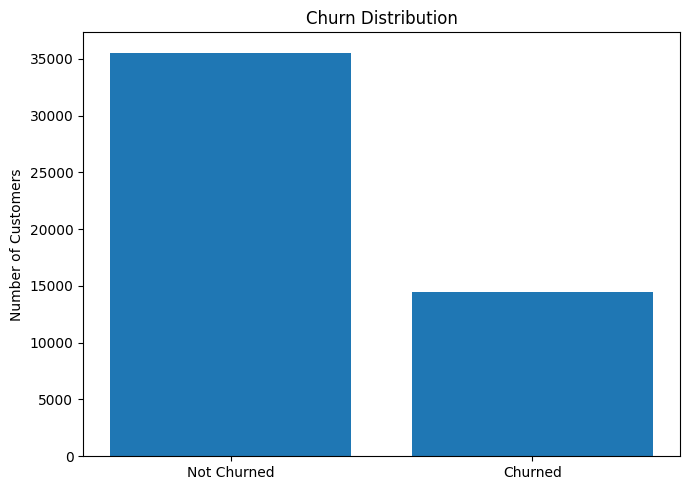

In [51]:
churn_counts = df[TARGET].value_counts().sort_index()
churn_pct = (churn_counts / len(df) * 100).round(2)

summary = pd.DataFrame({
    "Churn Status": ["Not Churned", "Churned"],
    "Customers": [churn_counts.get(0, 0), churn_counts.get(1, 0)],
    "Percentage": [churn_pct.get(0, 0), churn_pct.get(1, 0)],
})
display(summary)

plt.figure(figsize=(7, 5))
plt.bar(summary["Churn Status"], summary["Customers"])
plt.title("Churn Distribution")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## 5. Customer Segmentation with K-Means

The six core behavioral/customer features are used for clustering. The churn target is **not** used in clustering.

The scaler is fit on the complete dataset only for the descriptive segmentation stage. For the predictive stage later, the segmentation model is fitted using the training data only before assigning test-set segments.

In [52]:
segment_features = CORE_FEATURES.copy()

# Descriptive segmentation on the full cleaned dataset.
segment_preprocessor_full = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_segment_full = segment_preprocessor_full.fit_transform(df[segment_features])

print("Segmentation features:")
print(segment_features)

Segmentation features:
['Age', 'Total_Purchases', 'Login_Frequency', 'Session_Duration_Avg', 'Discount_Usage_Rate', 'Customer_Service_Calls']


### 5.1 Elbow Method

The Elbow Method is used to inspect the change in within-cluster sum of squares (inertia) across candidate values of K.

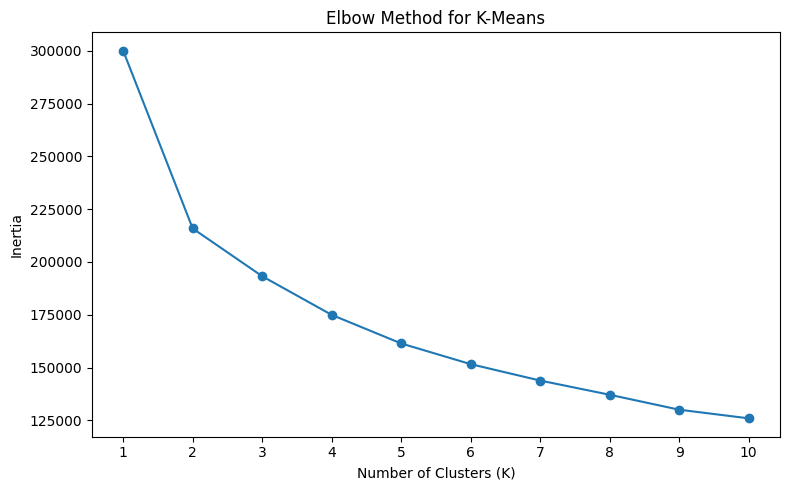

In [53]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_segment_full)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

### 5.2 Silhouette Score

Silhouette scores provide an additional objective measure of cluster separation and cohesion. The K with the highest score is selected for the final descriptive segmentation.

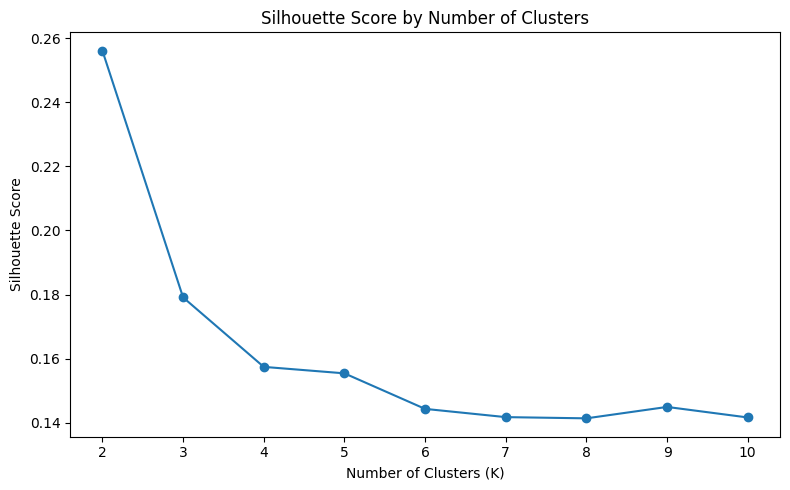

Silhouette scores:
K=2: 0.2561
K=3: 0.1791
K=4: 0.1574
K=5: 0.1554
K=6: 0.1443
K=7: 0.1418
K=8: 0.1414
K=9: 0.1449
K=10: 0.1417

Selected K based on highest Silhouette Score: 2


In [54]:
silhouette_scores = {}

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_segment_full)
    silhouette_scores[k] = silhouette_score(X_segment_full, labels)

best_k = max(silhouette_scores, key=silhouette_scores.get)

plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(silhouette_scores.keys()))
plt.tight_layout()
plt.show()

print("Silhouette scores:")
for k, score in silhouette_scores.items():
    print(f"K={k}: {score:.4f}")

print(f"\nSelected K based on highest Silhouette Score: {best_k}")

### 5.3 Final K-Means Segmentation

The selected K is used to assign every customer to a segment. Segment labels are identifiers only; their business meaning is established through profiling.

In [55]:
kmeans_full = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)
df["Segment"] = kmeans_full.fit_predict(X_segment_full)

segment_profile = df.groupby("Segment")[CORE_FEATURES].mean().round(2)
display(segment_profile)

,Age,Total_Purchases,Login_Frequency,Session_Duration_Avg,Discount_Usage_Rate,Customer_Service_Calls
Segment,,,,,,
0,37.80,18.94,18.71,37.43,42.32,4.03
1,37.81,9.52,7.27,21.11,41.80,6.70


### 5.4 PCA Visualization

PCA is used only for visualization of the standardized feature space. It does not determine the clusters.

Explained variance ratio: [0.4246 0.167 ]
Total variance explained by two components: 0.5916


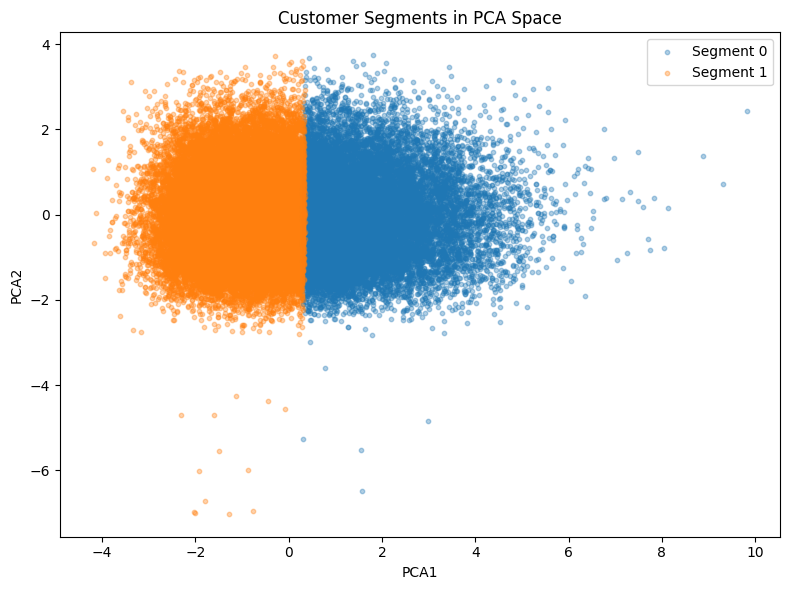

In [56]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
components = pca.fit_transform(X_segment_full)

df["PCA1"] = components[:, 0]
df["PCA2"] = components[:, 1]

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print("Total variance explained by two components:",
      round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(8, 6))
for segment in sorted(df["Segment"].unique()):
    subset = df[df["Segment"] == segment]
    plt.scatter(subset["PCA1"], subset["PCA2"], s=10, alpha=0.35, label=f"Segment {segment}")

plt.title("Customer Segments in PCA Space")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.tight_layout()
plt.show()

### 5.5 Segment Profiling and Churn

Observed churn rates are compared across segments. These are descriptive associations and should not be interpreted as causal effects.

,Segment,Customers,Churn_Rate,Login_Frequency,Session_Duration_Avg,Total_Purchases,Discount_Usage_Rate,Customer_Service_Calls
0,0,19040,18.67,18.71,37.43,18.94,42.32,4.03
1,1,30960,35.19,7.27,21.11,9.52,41.80,6.70


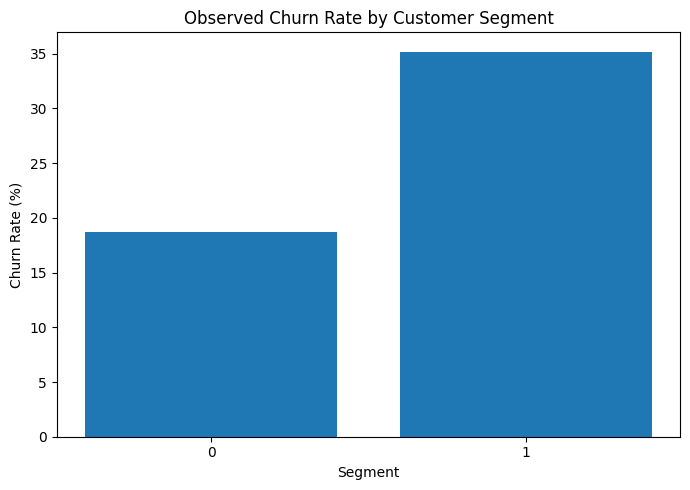

In [57]:
segment_summary = df.groupby("Segment").agg(
    Customers=(TARGET, "size"),
    Churn_Rate=(TARGET, "mean"),
    Login_Frequency=("Login_Frequency", "mean"),
    Session_Duration_Avg=("Session_Duration_Avg", "mean"),
    Total_Purchases=("Total_Purchases", "mean"),
    Discount_Usage_Rate=("Discount_Usage_Rate", "mean"),
    Customer_Service_Calls=("Customer_Service_Calls", "mean"),
).reset_index()

segment_summary["Churn_Rate"] = (segment_summary["Churn_Rate"] * 100).round(2)
segment_summary = segment_summary.round(2)

display(segment_summary)

plt.figure(figsize=(7, 5))
plt.bar(
    segment_summary["Segment"].astype(str),
    segment_summary["Churn_Rate"]
)
plt.title("Observed Churn Rate by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

## 6. Fair Predictive Modeling Setup

For predictive evaluation, a **single stratified 80/20 train-test split** is used for all models.

Three models/feature configurations are compared:

1. **Logistic Regression — six core features**  
2. **Random Forest — six core features**  
3. **Random Forest + K-Means Segment — six core features plus segment**

This design allows us to distinguish the contribution of the predictive algorithm from the possible contribution of customer segmentation.

In [58]:
X_core = df[CORE_FEATURES].copy()
y = df[TARGET].copy()

X_train_core, X_test_core, y_train, y_test = train_test_split(
    X_core,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training samples:", len(X_train_core))
print("Testing samples:", len(X_test_core))
print("\nTraining churn distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(4))
print("\nTesting churn distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(4))

Training samples: 40000
Testing samples: 10000

Training churn distribution:
Churned
0    0.711
1    0.289
Name: proportion, dtype: float64

Testing churn distribution:
Churned
0    0.711
1    0.289
Name: proportion, dtype: float64


## 7. Train/Assign Segments Without Test-Set Leakage

To use segment as a predictive feature fairly, K-Means is fitted **only on the training data**. The fitted scaler and K-Means model then assign segments to the held-out test data.

This prevents information from the test set from influencing the segment construction used for prediction.

In [59]:
segment_preprocessor_train = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_train_seg_processed = segment_preprocessor_train.fit_transform(X_train_core)

kmeans_train = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)
train_segments = kmeans_train.fit_predict(X_train_seg_processed)
test_segments = kmeans_train.predict(
    segment_preprocessor_train.transform(X_test_core)
)

X_train_with_segment = X_train_core.copy()
X_test_with_segment = X_test_core.copy()

X_train_with_segment["Segment"] = train_segments
X_test_with_segment["Segment"] = test_segments

print("Training segment counts:")
print(pd.Series(train_segments).value_counts().sort_index())
print("\nTesting segment counts:")
print(pd.Series(test_segments).value_counts().sort_index())

Training segment counts:
0    24924
1    15076
Name: count, dtype: int64

Testing segment counts:
0    6233
1    3767
Name: count, dtype: int64


## 8. Evaluation Helper

Accuracy is reported together with precision, recall, F1-score and ROC-AUC. Because churn is the positive class, precision/recall/F1 for class 1 are especially important.

In [60]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    else:
        proba = None

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, proba) if proba is not None else np.nan,
    }

    print(f"\n{name}")
    print("-" * len(name))
    print(classification_report(y_test, pred, digits=4, zero_division=0))
    print(f"ROC-AUC: {result['ROC_AUC']:.4f}")

    return model, pred, proba, result

## 9. Logistic Regression Baseline

Logistic Regression is used as an interpretable baseline. Standardization is performed inside a scikit-learn `Pipeline`, with the scaler fitted only on the training data.

In [61]:
lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

lr_model, lr_pred, lr_proba, lr_result = evaluate_model(
    "Logistic Regression — Core Features",
    lr_pipeline,
    X_train_core,
    X_test_core,
    y_train,
    y_test,
)



Logistic Regression — Core Features
-----------------------------------
              precision    recall  f1-score   support

           0     0.7491    0.9329    0.8309      7110
           1     0.5834    0.2311    0.3311      2890

    accuracy                         0.7301     10000
   macro avg     0.6662    0.5820    0.5810     10000
weighted avg     0.7012    0.7301    0.6865     10000

ROC-AUC: 0.7194


### 9.1 Logistic Regression Interpretation

Odds ratios are calculated from the fitted standardized coefficients. These describe the multiplicative change in the odds of churn associated with a one-standard-deviation increase in each feature, holding the other predictors constant.

In [62]:
lr_estimator = lr_model.named_steps["model"]

lr_coefficients = pd.DataFrame({
    "Feature": CORE_FEATURES,
    "Coefficient": lr_estimator.coef_[0],
    "Odds_Ratio": np.exp(lr_estimator.coef_[0]),
}).sort_values("Odds_Ratio", ascending=False)

display(lr_coefficients.round(4))

,Feature,Coefficient,Odds_Ratio
5,Customer_Service_Calls,0.5472,1.7284
1,Total_Purchases,0.0480,1.0491
2,Login_Frequency,-0.1909,0.8262
4,Discount_Usage_Rate,-0.1910,0.8261
3,Session_Duration_Avg,-0.2575,0.7730
0,Age,-0.2716,0.7622


## 10. Random Forest — Same Six Core Features

Random Forest is evaluated using exactly the same six core features and the same train/test split, making the comparison with Logistic Regression fair.

In [63]:
rf_core = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_core_model, rf_core_pred, rf_core_proba, rf_core_result = evaluate_model(
    "Random Forest — Core Features",
    rf_core,
    X_train_core,
    X_test_core,
    y_train,
    y_test,
)


Random Forest — Core Features
-----------------------------
              precision    recall  f1-score   support

           0     0.8136    0.9018    0.8554      7110
           1     0.6706    0.4917    0.5674      2890

    accuracy                         0.7833     10000
   macro avg     0.7421    0.6968    0.7114     10000
weighted avg     0.7723    0.7833    0.7722     10000

ROC-AUC: 0.8159


## 11. Random Forest + Customer Segment

This model tests whether adding the K-Means segment label provides incremental predictive value beyond the six core features.

In [64]:
rf_segment = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_segment_model, rf_segment_pred, rf_segment_proba, rf_segment_result = evaluate_model(
    "Random Forest — Core Features + Segment",
    rf_segment,
    X_train_with_segment,
    X_test_with_segment,
    y_train,
    y_test,
)


Random Forest — Core Features + Segment
---------------------------------------
              precision    recall  f1-score   support

           0     0.8147    0.9039    0.8570      7110
           1     0.6765    0.4941    0.5711      2890

    accuracy                         0.7855     10000
   macro avg     0.7456    0.6990    0.7140     10000
weighted avg     0.7747    0.7855    0.7744     10000

ROC-AUC: 0.8165


## 12. Model Comparison

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression — Core Features,0.7301,0.5834,0.2311,0.3311,0.7194
Random Forest — Core Features,0.7833,0.6706,0.4917,0.5674,0.8159
Random Forest — Core Features + Segment,0.7855,0.6765,0.4941,0.5711,0.8165


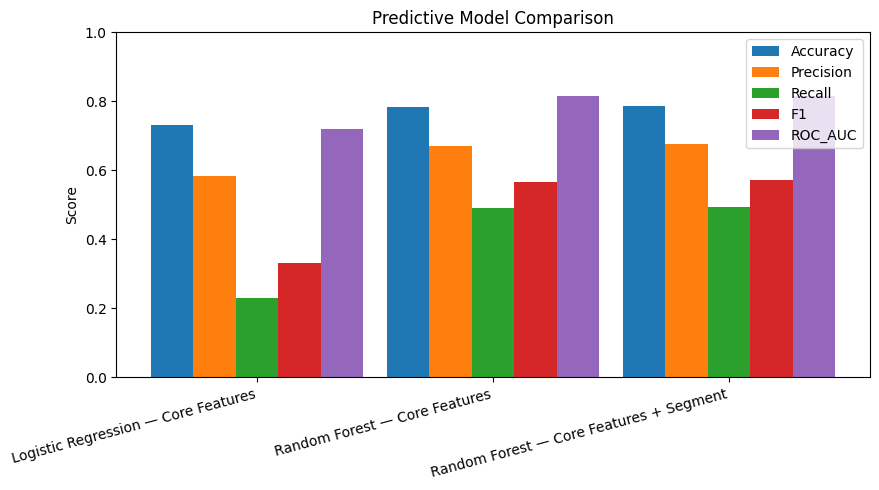

In [65]:
results = pd.DataFrame([
    lr_result,
    rf_core_result,
    rf_segment_result,
])

display(
    results.set_index("Model").style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
    })
)

plt.figure(figsize=(9, 5))
x = np.arange(len(results))
width = 0.18

for i, metric in enumerate(["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]):
    plt.bar(x + (i - 2) * width, results[metric], width, label=metric)

plt.xticks(x, results["Model"], rotation=15, ha="right")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Predictive Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Confusion Matrices

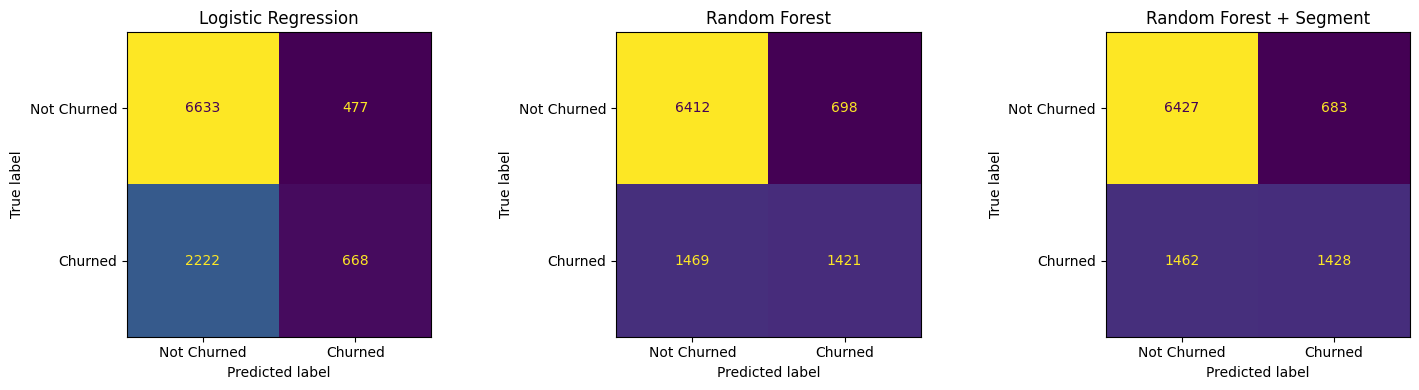

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_and_preds = [
    ("Logistic Regression", lr_pred),
    ("Random Forest", rf_core_pred),
    ("Random Forest + Segment", rf_segment_pred),
]

for ax, (name, pred) in zip(axes, models_and_preds):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Churned", "Churned"]
    )
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 14. Random Forest Feature Importance

Feature importance is examined for the Random Forest model with the segment feature. The result is used for business interpretation, not causal inference.

,Feature,Importance
4,Discount_Usage_Rate,0.2251
3,Session_Duration_Avg,0.1833
0,Age,0.1779
1,Total_Purchases,0.1565
5,Customer_Service_Calls,0.1409
2,Login_Frequency,0.1074
6,Segment,0.0089


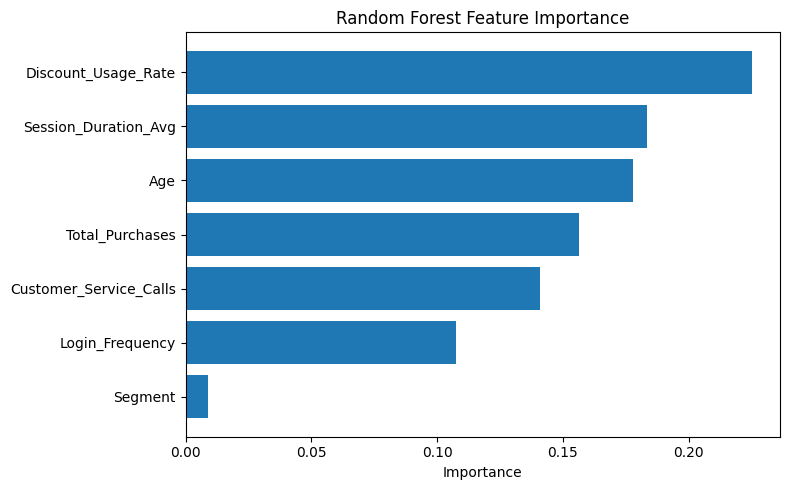

In [67]:
rf_estimator = rf_segment_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": X_train_with_segment.columns,
    "Importance": rf_estimator.feature_importances_,
}).sort_values("Importance", ascending=False)

display(feature_importance.round(4))

plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 15. Optional Cross-Validation Check

A stratified 5-fold ROC-AUC cross-validation is provided as an additional robustness check for the two core-feature predictive models. The final journal paper should report these values if the analysis is retained.

In [68]:
# Stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Logistic Regression CV pipeline
lr_cv_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

# Random Forest CV pipeline
rf_cv_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Logistic Regression cross-validation
lr_cv = cross_val_score(
    lr_cv_pipeline,
    X_core,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Random Forest cross-validation
rf_cv = cross_val_score(
    rf_cv_pipeline,
    X_core,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Summary
cv_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Mean_ROC_AUC": [lr_cv.mean(), rf_cv.mean()],
    "Std_ROC_AUC": [lr_cv.std(), rf_cv.std()],
})

display(cv_summary.round(4))

,Model,Mean_ROC_AUC,Std_ROC_AUC
0,Logistic Regression,0.7154,0.0052
1,Random Forest,0.8186,0.0034


## 16. Final Business Insight Table

This table combines segment-level descriptive findings with the predictive-model results. Segment labels should be interpreted from their profiles rather than from the numeric label itself.

In [69]:
# Create a compact research-results summary
best_model_row = results.loc[results["ROC_AUC"].idxmax()]

research_summary = {
    "Dataset Size": len(df),
    "Selected K": int(best_k),
    "Best Silhouette Score": round(silhouette_scores[best_k], 4),
    "Best Predictive Model": best_model_row["Model"],
    "Best Model Accuracy": round(best_model_row["Accuracy"], 4),
    "Best Model Precision": round(best_model_row["Precision"], 4),
    "Best Model Recall": round(best_model_row["Recall"], 4),
    "Best Model F1": round(best_model_row["F1"], 4),
    "Best Model ROC-AUC": round(best_model_row["ROC_AUC"], 4),
}

display(pd.DataFrame([research_summary]))

,Dataset Size,Selected K,Best Silhouette Score,Best Predictive Model,Best Model Accuracy,Best Model Precision,Best Model Recall,Best Model F1,Best Model ROC-AUC
0,50000,2,0.2561,Random Forest — Core Features + Segment,0.7855,0.6765,0.4941,0.5711,0.8165


## 17. Save Reproducible Artifacts

The final fitted models below are trained on the **full cleaned dataset** for deployment/repository use only, after predictive evaluation has been completed. These deployment artifacts should not be confused with the held-out test-set evaluation results reported in the paper.

The same feature definitions and preprocessing objects are saved so the Flask application can reproduce predictions consistently.

In [70]:
import os
import joblib

os.makedirs(MODEL_DIR, exist_ok=True)

# Fit final Logistic Regression pipeline on all available cleaned data
final_lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])
final_lr_pipeline.fit(X_core, y)

# Fit final segmentation components on all data for deployment
final_segment_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
X_all_seg_processed = final_segment_preprocessor.fit_transform(X_core)

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)
final_segments = final_kmeans.fit_predict(X_all_seg_processed)

X_all_with_segment = X_core.copy()
X_all_with_segment["Segment"] = final_segments

final_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])
final_rf.fit(X_all_with_segment, y)

joblib.dump(final_lr_pipeline, os.path.join(MODEL_DIR, "logistic_regression_pipeline.pkl"))
joblib.dump(final_rf, os.path.join(MODEL_DIR, "random_forest_segment_model.pkl"))
joblib.dump(final_segment_preprocessor, os.path.join(MODEL_DIR, "segment_preprocessor.pkl"))
joblib.dump(final_kmeans, os.path.join(MODEL_DIR, "kmeans_segment_model.pkl"))

print("Saved final deployment artifacts to:", MODEL_DIR)
print("- logistic_regression_pipeline.pkl")
print("- random_forest_segment_model.pkl")
print("- segment_preprocessor.pkl")
print("- kmeans_segment_model.pkl")

Saved final deployment artifacts to: ../models
- logistic_regression_pipeline.pkl
- random_forest_segment_model.pkl
- segment_preprocessor.pkl
- kmeans_segment_model.pkl


## 18. Research Reporting Checklist

Before transferring results into the journal manuscript:

- [ ] Run the notebook from the first cell to the last cell.
- [ ] Record the final selected K and Silhouette Score.
- [ ] Record segment sizes and observed churn rates.
- [ ] Record PCA explained variance.
- [ ] Record Logistic Regression metrics.
- [ ] Record Random Forest metrics using the same six features.
- [ ] Record Random Forest + Segment metrics.
- [ ] Report precision, recall, F1 and ROC-AUC, not accuracy alone.
- [ ] Report feature importance as an association/importance measure, not a causal effect.
- [ ] Keep the train/test split fixed at `random_state=42`.
- [ ] Do not use the held-out test set to fit preprocessing or clustering models.
- [ ] Update the manuscript only with numbers generated by this final notebook.